# SABR interpolation on cleaned historical data — unified-grid demo

Same **dataset** as in `docs/sabr_interpolation.md` (processed parquet from `data_pipeline.py` → `clean_data` → `processed.parquet`). Pick any **evaluation** grids `k_grid` and `tau_grid` for the dense surface; they do not need to match a kernel smoother.

Interpolation follows the repo SABR path: **per-expiry** `(α, ρ, ν)` with fixed `β`, then **`implied_vol_surface_from_calibrated_slices`** (Hagan lognormal `sabr_lognormal_iv` on each grid point), wired for historic quotes by **`build_historical_sabr_surface`** (`filter_day_for_surface`, expiry grouping, `m = exp(k)` for moneyness).

This notebook also demonstrates **pixel consistency** across historical, synthetic SABR and synthetic Heston sources via the shared `UnifiedGrid` (`config/unified_iv_grid.yaml`, `k ∈ [−0.5, 0.5]`, `τ ∈ [0.05, 2.0]`) and the per-pixel `SurfaceNormalizer` that maps every surface to a common `z`-score of `log σ`. See `docs/unified_grid_and_normalization.md`.

Run with `pip install -e .` from the repo root.

In [30]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from implied_volatility_diffusion import (
    SurfaceNormalizer,
    UnifiedGrid,
    denormalize_surface,
    implied_vol_surfaces_lhs,
    load_heston_iv_surface_config,
    merge_config,
    merge_config_files,
    resample_to_unified_grid,
)
from implied_volatility_diffusion.data.historical_data_smoothing_interpolation import (
    load_cleaned_data,
    plot_smile,
    plot_surface_3d,
)
from implied_volatility_diffusion.data.historical_sabr_interpolation import (
    build_historical_sabr_surface,
)
from implied_volatility_diffusion.synthetic.sabr import implied_vol_surfaces_sabr_lhs

## Load cleaned data

Default path matches `config/data_pipeline_config.yaml` (`processed_output_path`).

In [31]:
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd

processed_data_path = repo_root / "data" / "processed" / "processed.parquet"
df = load_cleaned_data(processed_data_path)

sample_date = pd.Timestamp("2021-06-17")
day = df[df["quote_date"] == sample_date].copy()
print("cleaned dataset:", processed_data_path)
print("sample_date:", sample_date, "rows (this day):", len(day))

r, q, beta = 0.03, 0.0, 0.5

cleaned dataset: /Users/sbonelomdluli/Desktop/implied-volatility-diffusion/data/processed/processed.parquet
sample_date: 2021-06-17 00:00:00 rows (this day): 14699


## SABR dense surface on the **unified grid**

We use `UnifiedGrid.default()` — `k ∈ [−0.5, 0.5]`, `τ ∈ [0.05, 2.0]`, shape `(41, 40)` — so the historical SABR surface shares pixels with everything the synthetic SABR / Heston generators produce.

In [32]:
unified_grid = UnifiedGrid.load(repo_root / "config" / "unified_iv_grid.yaml")
k_grid = unified_grid.log_moneyness
tau_grid = unified_grid.tau
KGRID, TAUGRID = unified_grid.meshgrid()
print("unified grid:", unified_grid.shape, "k in", (k_grid[0], k_grid[-1]), "tau in", (tau_grid[0], tau_grid[-1]))

sabr_out = build_historical_sabr_surface(day, k_grid, tau_grid, r=r, q=q, beta=beta)
Z_sabr_hist = sabr_out.surface

print("historical SABR — rows:", len(sabr_out.day_sub), "surface shape:", Z_sabr_hist.shape)
print("finite:", np.isfinite(Z_sabr_hist).sum(), "/", Z_sabr_hist.size, "spot:", sabr_out.spot)
print("(alpha, rho, nu) per expiry:\n", sabr_out.calibrated_params)

unified grid: (41, 40) k in (np.float64(-0.5), np.float64(0.5000000000000003)) tau in (np.float64(0.05), np.float64(2.000000000000001))
historical SABR — rows: 12812 surface shape: (41, 40)
finite: 1640 / 1640 spot: 4221.88
(alpha, rho, nu) per expiry:
 [[ 3.60780767 -0.46402666 12.1418079 ]
 [ 4.82171732 -0.53363283  9.5501019 ]
 [ 6.10293073 -0.51142184  7.41873753]
 [ 6.05210469 -0.52693137  6.19152321]
 [ 6.63298143 -0.29733808  5.54805986]
 [ 5.61716971 -0.16981528  5.96876314]
 [ 6.36746339 -0.48735924  5.00612725]
 [ 6.47423226 -0.55973258  4.91816148]
 [ 6.91433853 -0.61023275  4.50531858]
 [ 6.90983342 -0.62824667  4.22174732]
 [ 7.10772944 -0.62981855  4.05764949]
 [ 6.8796608  -0.68991918  4.24476715]
 [ 7.18743742 -0.71327162  3.9628418 ]
 [ 7.37266126 -0.69954729  3.66710199]
 [ 7.50781592 -0.70468754  3.45400885]
 [ 7.93650618 -0.7009428   3.07727881]
 [ 8.37232554 -0.66556307  2.4000613 ]
 [ 8.74225664 -0.67710407  2.20915421]
 [ 9.18053338 -0.67902545  1.88104591]
 [ 9.

## Plots

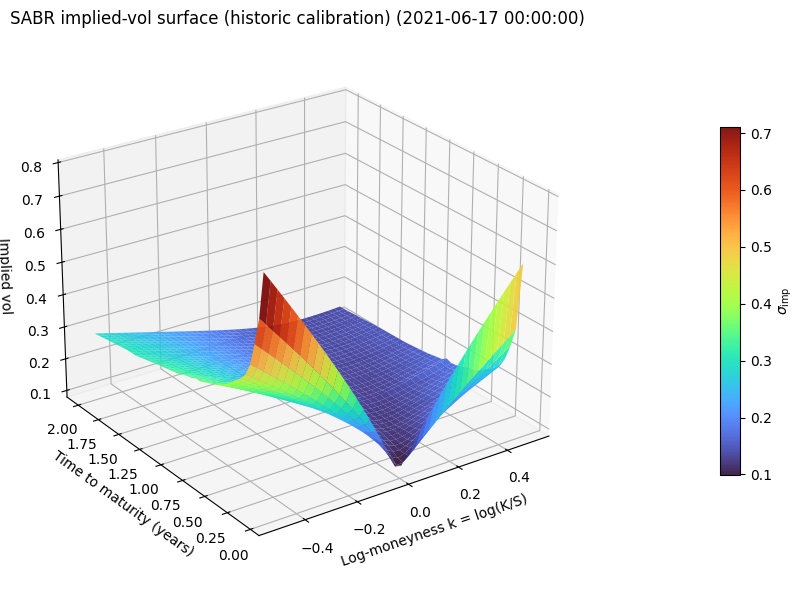

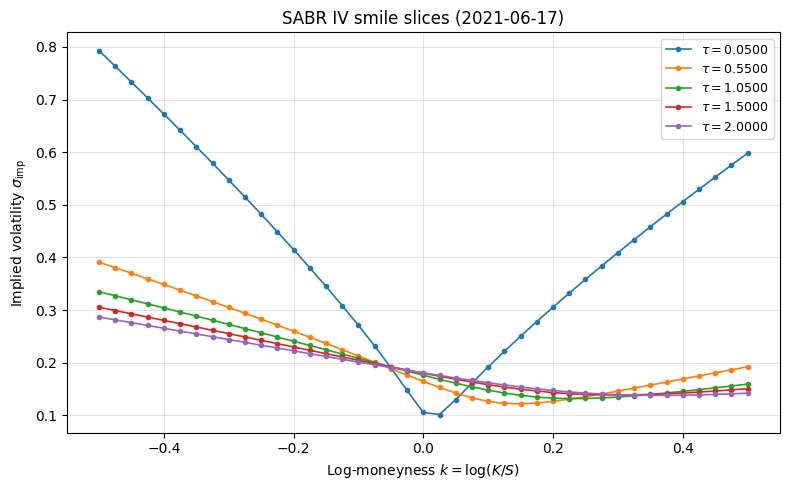

In [33]:
plot_surface_3d(
    KGRID,
    TAUGRID,
    Z_sabr_hist,
    sample_date,
    title="SABR implied-vol surface (historic calibration)",
)

plot_smile(
    k_grid,
    tau_grid,
    Z_sabr_hist,
    sample_date,
    title="SABR IV smile slices",
)

## Cross-model pixel consistency

The unified grid pins the pixel coordinates `(k_i, τ_j)`. We now also build:

1. a **synthetic SABR** batch, and
2. a **synthetic Heston** batch,

on the **same** unified grid by feeding each generator the config returned by `UnifiedGrid.with_config(cfg)`. Every surface ends up with shape `(41, 40)` and identical `(k, τ)` axes, so pixel `(i, j)` in the historical surface and pixel `(i, j)` in any synthetic surface refer to the same economic cell.

In [34]:
config_dir = repo_root / "config"

sabr_cfg = unified_grid.with_config(merge_config_files(config_dir / "sabr_iv_surface.yaml"))
sabr_cfg = merge_config(sabr_cfg, {"lhs": {"n_samples": 32, "n_batches": 1, "seed": 21}})
_, m_sabr, tau_sabr, iv_sabr_synth = implied_vol_surfaces_sabr_lhs(sabr_cfg)
print("synthetic SABR   :", iv_sabr_synth.shape)

heston_cfg = unified_grid.with_config(load_heston_iv_surface_config(config_dir))
heston_cfg = merge_config(heston_cfg, {"lhs": {"n_samples": 32, "n_batches": 1, "seed": 11}})
_, m_hest, tau_hest, iv_heston_synth = implied_vol_surfaces_lhs(heston_cfg)
print("synthetic Heston :", iv_heston_synth.shape)

assert np.allclose(m_sabr, unified_grid.moneyness) and np.allclose(tau_sabr, unified_grid.tau)
assert np.allclose(m_hest, unified_grid.moneyness) and np.allclose(tau_hest, unified_grid.tau)
print("grid axes identical across historical / synthetic SABR / synthetic Heston ✓")

synthetic SABR   : (32, 41, 40)
synthetic Heston : (32, 41, 40)
grid axes identical across historical / synthetic SABR / synthetic Heston ✓


### Fit the per-pixel `log σ` normalizer on the combined training set

For each pixel `(i, j)` we compute the historical mean `μ_{i,j}` and std `σ_{norm, i,j}` of `log σ` across every surface in the combined training stack (historical SABR surface + synthetic SABR batch + synthetic Heston batch). After normalization

$$\tilde z^{(n)}_{i,j} = \frac{\log \sigma^{(n)}_{i,j} - \mu_{i,j}}{\sigma_{\text{norm}, i, j}}$$

a value of `0.0` at pixel `(i, j)` **always** means "historical mean log-IV for that specific `(k_i, τ_j)` cell" — regardless of whether the surface came from a SABR model, a Heston model or the 2021 SPX market.

In [35]:
combined = np.concatenate(
    [Z_sabr_hist[None, ...], iv_sabr_synth, iv_heston_synth],
    axis=0,
)
print("combined training stack:", combined.shape)

normalizer = SurfaceNormalizer(grid_shape=unified_grid.shape).fit(combined)
print("fitted pixels:", int(np.sum(normalizer.count > 0)), "/", unified_grid.shape[0] * unified_grid.shape[1])
print("mean(log σ) range :", float(np.nanmin(normalizer.mean)), "..", float(np.nanmax(normalizer.mean)))
print("std (log σ) range :", float(np.nanmin(normalizer.std)), "..", float(np.nanmax(normalizer.std)))

z_hist = normalizer.transform(Z_sabr_hist)
z_sabr = normalizer.transform(iv_sabr_synth)
z_heston = normalizer.transform(iv_heston_synth)
print("z-score shapes    :", z_hist.shape, z_sabr.shape, z_heston.shape)
print("|mean z| (synth SABR)   :", float(np.abs(np.nanmean(z_sabr))))
print("|mean z| (synth Heston) :", float(np.abs(np.nanmean(z_heston))))

atol = 1e-12
roundtrip = normalizer.inverse_transform(z_hist)
print(
    "inverse_transform round-trips historical surface:",
    bool(np.allclose(roundtrip, Z_sabr_hist, atol=atol, equal_nan=True)),
)

combined training stack: (65, 41, 40)
fitted pixels: 1640 / 1640
mean(log σ) range : -2.6226113556591604 .. -1.9451265078438
std (log σ) range : 1.1567886848517102 .. 1.9680663729426509
z-score shapes    : (41, 40) (32, 41, 40) (32, 41, 40)
|mean z| (synth SABR)   : 0.9414939943623492
|mean z| (synth Heston) : 0.9253942536961748
inverse_transform round-trips historical surface: True


### Raw vs. normalized — side-by-side

The raw surfaces live on very different scales (historical SABR vs. one synthetic SABR draw vs. one synthetic Heston draw). After per-pixel normalization they all sit on the same z-score scale where `0` = historical mean.

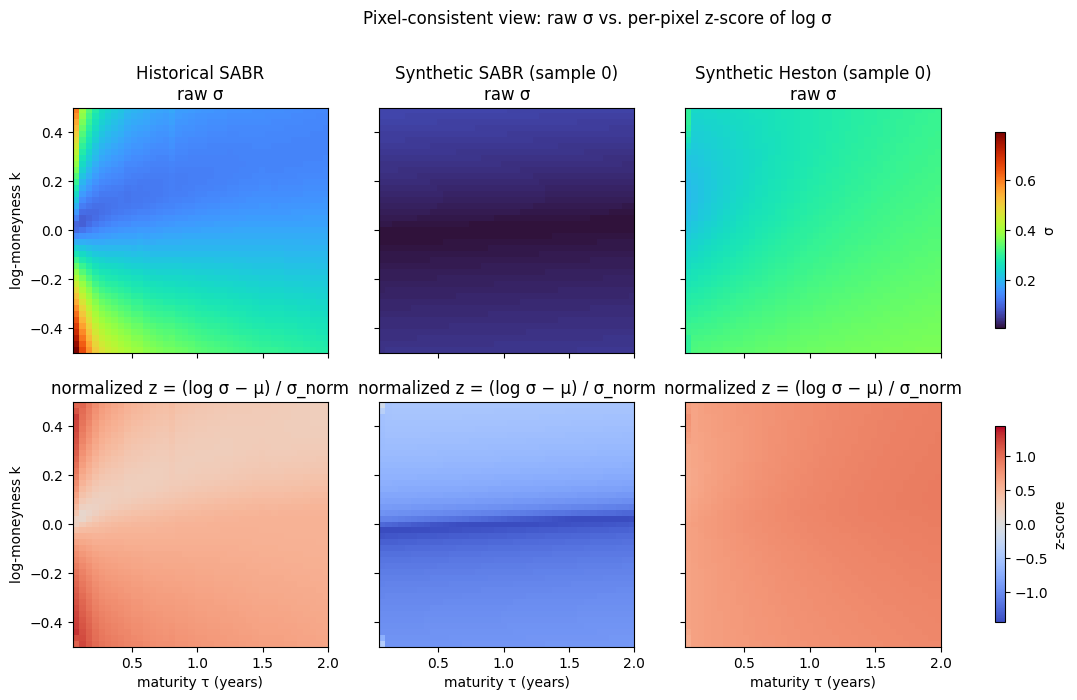

In [36]:
samples = [
    ("Historical SABR", Z_sabr_hist, z_hist),
    ("Synthetic SABR (sample 0)", iv_sabr_synth[0], z_sabr[0]),
    ("Synthetic Heston (sample 0)", iv_heston_synth[0], z_heston[0]),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
extent = (tau_grid[0], tau_grid[-1], k_grid[0], k_grid[-1])

raw_vmin = float(np.nanmin([np.nanmin(s[1]) for s in samples]))
raw_vmax = float(np.nanmax([np.nanmax(s[1]) for s in samples]))
z_abs = float(np.nanmax([np.nanmax(np.abs(s[2])) for s in samples]))

for col, (title, raw, z) in enumerate(samples):
    ax_raw = axes[0, col]
    im_raw = ax_raw.imshow(
        raw,
        origin="lower",
        aspect="auto",
        extent=extent,
        vmin=raw_vmin,
        vmax=raw_vmax,
        cmap="turbo",
    )
    ax_raw.set_title(f"{title}\nraw σ")
    if col == 0:
        ax_raw.set_ylabel("log-moneyness k")
    ax_z = axes[1, col]
    im_z = ax_z.imshow(
        z,
        origin="lower",
        aspect="auto",
        extent=extent,
        vmin=-z_abs,
        vmax=z_abs,
        cmap="coolwarm",
    )
    ax_z.set_title("normalized z = (log σ − μ) / σ_norm")
    ax_z.set_xlabel("maturity τ (years)")
    if col == 0:
        ax_z.set_ylabel("log-moneyness k")

fig.colorbar(im_raw, ax=axes[0, :], shrink=0.8, label="σ")
fig.colorbar(im_z, ax=axes[1, :], shrink=0.8, label="z-score")
fig.suptitle("Pixel-consistent view: raw σ vs. per-pixel z-score of log σ", y=1.02)
plt.show()

### Resampling a surface computed on a *different* grid

Historical kernel-smoothed surfaces are typically built on user-chosen `(k, τ)` axes. `resample_to_unified_grid` brings any such surface onto the canonical grid in one call — pixels outside the source coverage come back as `NaN`, matching the existing NaN contract of the kernel smoother.

In [37]:
k_src = np.linspace(-0.25, 0.25, 21)
tau_src = np.linspace(0.1, 1.5, 18)
sabr_src = build_historical_sabr_surface(day, k_src, tau_src, r=r, q=q, beta=beta).surface

Z_on_unified = resample_to_unified_grid(sabr_src, k_src=k_src, tau_src=tau_src, grid=unified_grid)
z_on_unified = normalizer.transform(Z_on_unified)

print("off-grid source   :", sabr_src.shape, "coverage:", (k_src[0], k_src[-1]), (tau_src[0], tau_src[-1]))
print("unified output    :", Z_on_unified.shape, "finite:", int(np.isfinite(Z_on_unified).sum()))
print("normalized output :", z_on_unified.shape, "finite:", int(np.isfinite(z_on_unified).sum()))
print("shares pixels with historical stack:", Z_on_unified.shape == unified_grid.shape)

normalizer.save(repo_root / "data" / "processed" / "iv_normalizer.npz")
print("saved normalizer to data/processed/iv_normalizer.npz")

off-grid source   : (21, 18) coverage: (np.float64(-0.25), np.float64(0.25)) (np.float64(0.1), np.float64(1.5))
unified output    : (41, 40) finite: 609
normalized output : (41, 40) finite: 609
shares pixels with historical stack: True
saved normalizer to data/processed/iv_normalizer.npz


## Denormalization — mapping z-scores back to implied vol

The inverse of the per-pixel normalization is

$$\sigma_{i,j}(z) = \exp\bigl(z_{i,j}\,\sigma_{\text{norm},\,i,j} + \mu_{i,j}\bigr).$$

Three equivalent entry points, pick whichever fits the call site:

1. `norm.denormalize(z)` — the canonical instance method.
2. `norm.inverse_transform(z)` — scikit-learn style alias.
3. `denormalize_surface(z, mean, std)` — stateless helper for consumers that
   only have the raw statistics arrays (e.g. loaded from a shared `.npz`).

All three satisfy `denormalize(normalize(σ)) == σ` up to the `iv_floor` clamp,
and in particular map `z = 0` to the historical mean `exp(μ)`.

In [38]:
iv_from_method = normalizer.denormalize(z_hist)
iv_from_inverse = normalizer.inverse_transform(z_hist)
iv_from_helper = denormalize_surface(z_hist, normalizer.mean, normalizer.std)

roundtrip_ok = np.allclose(iv_from_method, Z_sabr_hist, atol=1e-12, equal_nan=True)
methods_agree = np.allclose(iv_from_method, iv_from_inverse, atol=1e-15, equal_nan=True) and np.allclose(
    iv_from_method, iv_from_helper, atol=1e-15, equal_nan=True
)
print("denormalize(normalize(σ)) == σ :", roundtrip_ok)
print("method / inverse / helper agree:", methods_agree)

sigma_pixel_mean = normalizer.denormalize(np.zeros(unified_grid.shape))
max_dev = float(np.max(np.abs(sigma_pixel_mean - np.exp(normalizer.mean))))
print(f"denormalize(0) recovers exp(μ)  : max deviation = {max_dev:.2e}")

log_iv = normalizer.denormalize(z_hist, return_log_iv=True)
print(
    "return_log_iv=True shape         :", log_iv.shape, "min/max:", float(np.nanmin(log_iv)), float(np.nanmax(log_iv))
)

denormalize(normalize(σ)) == σ : True
method / inverse / helper agree: True
denormalize(0) recovers exp(μ)  : max deviation = 0.00e+00
return_log_iv=True shape         : (41, 40) min/max: -2.372842307289769 -0.23162092408904877


### Full pipeline visualization — raw → normalized → denormalized

The three canonical representations of a single surface, shown side by side:

1. **Raw σ** — the historical SABR-calibrated IV surface on the unified grid.
2. **Normalized z** — per-pixel z-score of `log σ`, i.e. `z = (log σ − μ) / σ_norm`.
3. **Denormalized σ** — the inverse `σ = exp(z · σ_norm + μ)`, which must round-trip to the raw input.

We plot each stage as a 2D heatmap (pixel view) and as a 3D surface (shape view). The raw and
denormalized columns should look identical; the normalized column is on a different scale entirely
(dimensionless z-scores, symmetric around 0).

raw surface       : shape=(41, 40), σ ∈ [0.0932, 0.7932]
normalized surface: shape=(41, 40),   z ∈ [+0.131, +1.297]
denormalized σ    : shape=(41, 40), σ ∈ [0.0932, 0.7932]
round-trip max|Δσ|: 2.22e-16


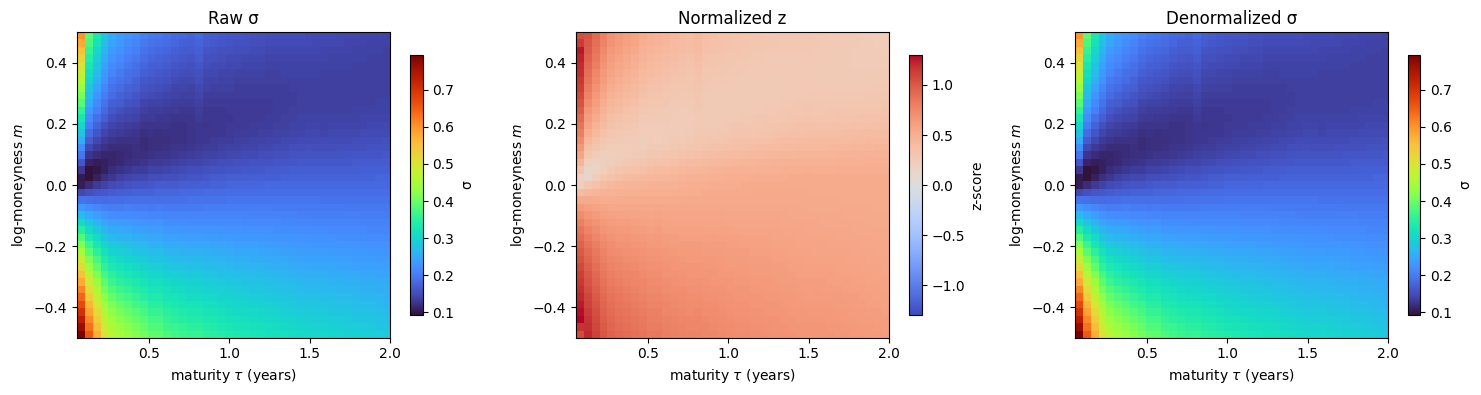

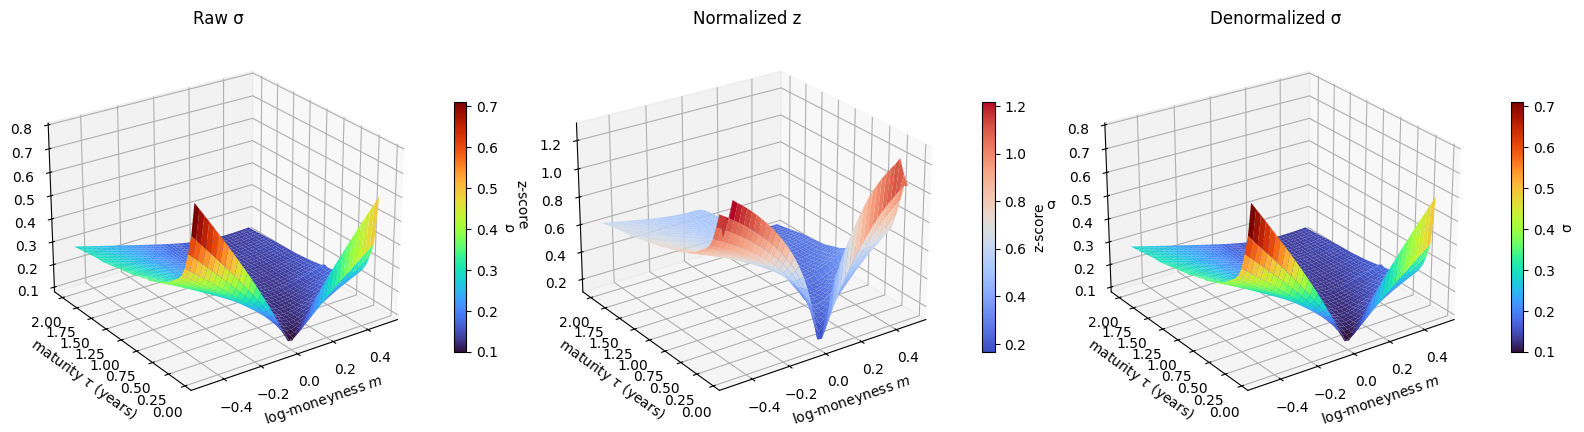

In [39]:
raw_surface = Z_sabr_hist
z_surface = normalizer.transform(raw_surface)
denorm_surface = normalizer.denormalize(z_surface)

roundtrip_err = float(np.nanmax(np.abs(denorm_surface - raw_surface)))
print(
    f"raw surface       : shape={raw_surface.shape}, σ ∈ [{np.nanmin(raw_surface):.4f}, {np.nanmax(raw_surface):.4f}]"
)
print(f"normalized surface: shape={z_surface.shape},   z ∈ [{np.nanmin(z_surface):+.3f}, {np.nanmax(z_surface):+.3f}]")
print(
    f"denormalized σ    : shape={denorm_surface.shape}, σ ∈ [{np.nanmin(denorm_surface):.4f}, {np.nanmax(denorm_surface):.4f}]"
)
print(f"round-trip max|Δσ|: {roundtrip_err:.2e}")

stages = [
    ("Raw σ", raw_surface, "σ", "turbo", None),
    ("Normalized z", z_surface, "z-score", "coolwarm", "symmetric"),
    ("Denormalized σ", denorm_surface, "σ", "turbo", None),
]

sigma_vmin = float(np.nanmin([raw_surface, denorm_surface]))
sigma_vmax = float(np.nanmax([raw_surface, denorm_surface]))
z_abs = float(np.nanmax(np.abs(z_surface)))
extent = (tau_grid[0], tau_grid[-1], k_grid[0], k_grid[-1])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (title, data, cbar_label, cmap, scale) in zip(axes, stages):
    if scale == "symmetric":
        vmin, vmax = -z_abs, z_abs
    else:
        vmin, vmax = sigma_vmin, sigma_vmax
    im = ax.imshow(
        data,
        origin="lower",
        aspect="auto",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
    )
    ax.set_title(title)
    ax.set_xlabel(r"maturity $\tau$ (years)")
    ax.set_ylabel(r"log-moneyness $m$")
    fig.colorbar(im, ax=ax, shrink=0.85, label=cbar_label)
fig.suptitle(
    "",
    y=1.03,
)
plt.tight_layout()
plt.savefig("normalization_roundtrip_heatmap.pdf", bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(16, 5))
for col, (title, data, cbar_label, cmap, scale) in enumerate(stages, start=1):
    ax = fig.add_subplot(1, 3, col, projection="3d")
    surf = ax.plot_surface(
        KGRID,
        TAUGRID,
        data,
        cmap=cmap,
        edgecolor="none",
        antialiased=True,
        rstride=1,
        cstride=1,
    )
    ax.set_title(title)
    ax.set_xlabel(r"log-moneyness $m$")
    ax.set_ylabel(r"maturity $\tau$ (years)")
    ax.set_zlabel(cbar_label)
    ax.view_init(elev=25, azim=235)
    fig.colorbar(surf, ax=ax, shrink=0.55, pad=0.08, label=cbar_label)
fig.suptitle(
    "",
    y=1.02,
)
plt.tight_layout()
plt.savefig("normalization_roundtrip_3d.pdf", bbox_inches="tight")
plt.show()

### Interpolating between the historical mean and a tail scenario

Denormalization is just `exp(z · σ_norm + μ)`, so sweeping `z` on a straight
line in normalized space gives a physically meaningful, per-pixel-consistent
family of IV surfaces. Here we sweep from the **historical mean** (`z = 0`) to
**two standard deviations above** (`z = +2`), the latter matching a stressed
high-vol regime. Notice that every produced surface shares pixel coordinates
with the training set, by construction.

z sweep batch: (5, 41, 40) -> sigma: (5, 41, 40)


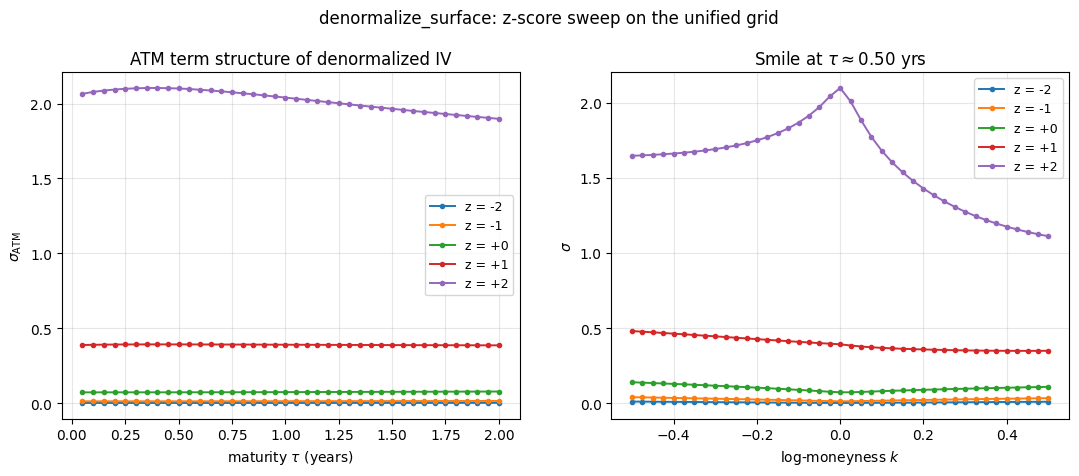

In [40]:
z_levels = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
z_batch = np.stack([np.full(unified_grid.shape, z) for z in z_levels])
sigma_batch = denormalize_surface(z_batch, normalizer.mean, normalizer.std)
print("z sweep batch:", z_batch.shape, "-> sigma:", sigma_batch.shape)

atm_idx = int(np.argmin(np.abs(unified_grid.log_moneyness)))
tau_axis = unified_grid.tau

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for z, sigma in zip(z_levels, sigma_batch):
    axes[0].plot(tau_axis, sigma[atm_idx, :], marker="o", ms=3, lw=1.4, label=f"z = {z:+.0f}")
axes[0].set_xlabel(r"maturity $\tau$ (years)")
axes[0].set_ylabel(r"$\sigma_{\mathrm{ATM}}$")
axes[0].set_title("ATM term structure of denormalized IV")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

mid_tau_idx = int(np.argmin(np.abs(tau_axis - 0.5)))
for z, sigma in zip(z_levels, sigma_batch):
    axes[1].plot(unified_grid.log_moneyness, sigma[:, mid_tau_idx], marker="o", ms=3, lw=1.4, label=f"z = {z:+.0f}")
axes[1].set_xlabel(r"log-moneyness $k$")
axes[1].set_ylabel(r"$\sigma$")
axes[1].set_title(rf"Smile at $\tau \approx {tau_axis[mid_tau_idx]:.2f}$ yrs")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

fig.suptitle("denormalize_surface: z-score sweep on the unified grid", y=1.02)
plt.show()

### Typical downstream use: denormalizing diffusion-model samples

Training a diffusion model on the pixel-consistent z-score surfaces means the
model's outputs are also z-score surfaces. To turn those back into tradeable
implied volatilities you just call `denormalize_surface` (or
`norm.denormalize`) on the batch — statelessly, with whatever `mean` / `std`
were shipped alongside the checkpoint.

In [41]:
rng = np.random.default_rng(0)
mock_diffusion_samples = rng.normal(size=(4, *unified_grid.shape))
iv_samples = denormalize_surface(mock_diffusion_samples, normalizer.mean, normalizer.std)

print(
    "mock diffusion samples (z-space):",
    mock_diffusion_samples.shape,
    f"mean={mock_diffusion_samples.mean():+.3f}",
    f"std={mock_diffusion_samples.std():.3f}",
)
print(
    "denormalized σ surfaces          :",
    iv_samples.shape,
    f"min={float(np.nanmin(iv_samples)):.4f}",
    f"median={float(np.nanmedian(iv_samples)):.4f}",
    f"max={float(np.nanmax(iv_samples)):.4f}",
)

saved = repo_root / "data" / "processed" / "iv_normalizer.npz"
stats = np.load(saved)
iv_from_disk = denormalize_surface(mock_diffusion_samples, stats["mean"], stats["std"])
print("matches stateless denorm from .npz:", np.allclose(iv_from_disk, iv_samples, atol=1e-15))

mock diffusion samples (z-space): (4, 41, 40) mean=-0.002 std=0.996
denormalized σ surfaces          : (4, 41, 40) min=0.0006 median=0.0990 max=11.6706
matches stateless denorm from .npz: True
